# Galaxy–CMB Lensing Cross-Correlation Pipeline for Cosmological Parameter Inference using PoCoMC and CosmoPower

*Estimate ΛCDM cosmological parameters (plus galaxy bias amplitude) from simulated observational spectra using Bayesian inference and neural-network emulated power spectra.*



| **Component**                | **Description**                                                                 |
|-----------------------------|---------------------------------------------------------------------------------|
| **Purpose**                 | Estimate cosmological parameters via galaxy–CMB lensing cross-correlation.     |
| **Core Model**              | Implements ΛCDM cosmology: Hubble function, growth factors, lensing kernels.   |
| **Power Spectrum**          | Uses CosmoPower (neural net emulator) to compute P(k, z).                      |
| **Angular Projection**      | Applies Limber approximation to project 3D spectra into 2D angular space.      |
| **Inference Method**        | Uses PoCoMC MCMC sampling with physical priors on key parameters.              |
| **Uncertainty Estimation**  | Constructs covariance matrices and log-likelihood function for robustness.     |
| **Result Visualization**    | Generates trace plots, histograms, and corner plots for posteriors.            |
| **Key Parameters Estimated**|  H₀, Ω_b h², Ω_c h², nₛ, Aₛ, b₀ from fiducial/simulated observational spectra. |

**Author**: Adrita Khan  
**Date**: 17.08.2025


- # **Installing/Upgrading Required Packages**

In [1]:
!pip install -q --upgrade pip
!pip install -q --upgrade pocomc cosmopower astropy getdist corner gdown statsmodels # Install or upgrade all required packages

- # **Suppress Warnings & Check Installed Package Versions**

In [2]:
import warnings
warnings.filterwarnings('ignore')  # Suppress warnings

from importlib.metadata import version, PackageNotFoundError

packages = ['pocomc', 'cosmopower', 'astropy', 'getdist', 'gdown', 'corner', 'statsmodels']  # Add more package names as needed

for pkg in packages:
    try:
        print(f"{pkg} version: {version(pkg)}")
    except PackageNotFoundError:
        print(f"{pkg} is not installed.")

pocomc version: 1.2.6
cosmopower version: 0.2.0
astropy version: 6.1.7
getdist version: 1.7.1
gdown version: 5.2.0
corner version: 2.2.3
statsmodels version: 0.14.5


- # **Import Essential Libraries**

**Suppress TensorFlow and warnings**

In [3]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # Suppress TensorFlow C++ backend info/warning logs

import tensorflow as tf
import warnings

tf.get_logger().setLevel('ERROR')  # Set TensorFlow Python logger to show only errors

# Suppress specific Python warning categories
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=UserWarning)

**Core cosmology and plotting libraries**

In [4]:
# Essential libraries for cosmology, sampling, and plotting
import gdown                        # Google Drive downloads
import numpy as np                   # Numerical operations
import matplotlib.pyplot as plt      # Plotting
from scipy.stats import uniform      # Distributions
import pocomc as pc                   # PoCoMC sampler
import cosmopower as cp               # Power spectrum emulator
from astropy.cosmology import FlatLambdaCDM, Planck18  # Cosmology models
from scipy.integrate import quad      # Integration
import getdist                        # MCMC analysis
from getdist import MCSamples, plots  # MCMC plotting
import corner                         # Posterior visualization

- # **Define Fiducial Parameters and Constants**

In [5]:
# Fiducial cosmological parameters
params = {
    'omega_b': [0.0225],        # Baryon density
    'omega_cdm': [0.113],       # Cold dark matter density
    'h': [0.7],                 # Hubble parameter
    'tau_reio': [0.055],        # Optical depth
    'n_s': [0.96],              # Spectral index
    'ln10^{10}A_s': [3.07],     # Scalar amplitude
    'b0': [2.0],                # Galaxy bias amplitude (fiducial)
}

# Constants
c = 299792.458  # Speed of light (km/s)
alpha = 2.225   # Magnification bias


- # **Load CosmoPower Emulator**

In [6]:
# CosmoPower Model Setup

# --- Step 1: Set Up CosmoPower Emulator ---
# Download pre-trained model

os.makedirs("home", exist_ok=True)  # Create dir
os.makedirs("plots", exist_ok=True)

gdown.download('https://drive.google.com/uc?id=1h-IxTLoyTE6L3_uE9omjDNC-8X_uVAie', 'home/PKLIN_NN.pkl', quiet=False)  # Download model

cp_nn = cp.cosmopower_NN(restore=True, restore_filename='home/PKLIN_NN')  # Load model

Downloading...
From: https://drive.google.com/uc?id=1h-IxTLoyTE6L3_uE9omjDNC-8X_uVAie
To: /teamspace/studios/this_studio/home/PKLIN_NN.pkl
100%|██████████| 3.00M/3.00M [00:00<00:00, 188MB/s]


- # **Shows emulator parameter values**

In [7]:
print('emulator parameters: ', cp_nn.parameters)

emulator parameters:  ListWrapper(['omega_b', 'omega_cdm', 'h', 'n_s', 'ln10^{10}A_s', 'z'])


- # **Displays sampled multipoles info**

In [8]:
modes = cp_nn.modes
print('sampled multipoles (first 5):', modes[:5])
print('sampled multipoles (last 5):', modes[-5:])
print('number of multipoles:', cp_nn.n_modes)

sampled multipoles (first 5): [1.00000000e-05 1.12201845e-05 1.25892541e-05 1.41253754e-05
 1.58489319e-05]
sampled multipoles (last 5): [9.08517576 9.26118728 9.44060876 9.62350626 9.80994713]
number of multipoles: 420


- # **Hidden layers count**  

In [9]:
print('hidden layers: ', cp_nn.n_hidden)

hidden layers:  ListWrapper([512, 512, 512])


- # **Define Core Cosmological Functions**

In [10]:
# Core Cosmological Functions
# --- Step 2: Helper Functions Based on Standard Cosmological Equations ---

# Hubble Function
def hubble_function(z, H0, Om_m, Om_lambda):
    return H0 * np.sqrt(Om_m * (1 + z)**3 + Om_lambda)

# Comoving Distance
def comoving_distance_proper(z, H0, Om_m, Om_lambda):
    def integrand(z_prime):
        return c / hubble_function(z_prime, H0, Om_m, Om_lambda)
    chi, _ = quad(integrand, 0, z)
    return chi

# Growth Factor D(z)
def growth_factor_D(z, H0, Om_m, Om_lambda):
    g_z = growth_function_g(z, H0, Om_m, Om_lambda)
    return g_z / (1 + z)

# Growth Function g(z)
def growth_function_g(z, H0, Om_m, Om_lambda):
    Omega_z = compute_Omega_z(z, H0, Om_m, Om_lambda)
    lambda_z = compute_lambda_z(z, H0, Om_m, Om_lambda)
    denominator = Omega_z**(4/7) - lambda_z + (1 + Omega_z/2) * (1 + lambda_z/70)
    return (5 * Omega_z / 2) * (1 / denominator)

# Omega(z)
def compute_Omega_z(z, H0, Om_m, Om_lambda):
    numerator = Om_m * (1 + z)**3
    denominator = Om_m * (1 + z)**3 + (1 - Om_m - Om_lambda) * (1 + z)**2 + Om_lambda
    return numerator / denominator

# Lambda(z)
def compute_lambda_z(z, H0, Om_m, Om_lambda):
    numerator = Om_lambda
    denominator = Om_m * (1 + z)**3 + (1 - Om_m - Om_lambda) * (1 + z)**2 + Om_lambda
    return numerator / denominator

# CMB Lensing Kernel
def cmb_lensing_kernel(z, z_star, H0, Om_m, Om_lambda):
    chi_z = comoving_distance_proper(z, H0, Om_m, Om_lambda)
    chi_star = comoving_distance_proper(z_star, H0, Om_m, Om_lambda)
    prefactor = (3 * Om_m * H0**2) / (2 * c)
    return prefactor * (1 + z) * chi_z * (chi_star - chi_z) / chi_star

# Galaxy Lensing Kernel
def galaxy_lensing_kernel(z, z_array, dN_dz_func, bias_func, H0, Om_m, Om_lambda):
    bias_term = bias_func(z) * dN_dz_func(z)
    chi_z = comoving_distance_proper(z, H0, Om_m, Om_lambda)

    def integrand(z_prime):
        chi_z_prime = comoving_distance_proper(z_prime, H0, Om_m, Om_lambda)
        return (1 - chi_z / chi_z_prime) * (alpha - 1) * dN_dz_func(z_prime)

    z_star = 10.0
    integral_term, _ = quad(integrand, z, z_star)
    mu_prefactor = (3 * Om_m * H0**2) / (2 * c) * (1 + z) * chi_z
    mu_z = mu_prefactor * integral_term
    return bias_term + mu_z

# Bias Function
def bias_function(z, b0=2.0):
    D_star_z = growth_factor_D(z, 70.0, 0.3, 0.7) / growth_factor_D(0, 70.0, 0.3, 0.7)
    return b0 / D_star_z

# Galaxy Redshift Distribution
def galaxy_number_density(z):
    z0 = 0.3
    return np.exp(-z / z0)

# Cross-Correlation Spectrum (Limber Approximation)
def cross_correlation_spectrum_proper(z1, z2, H0, Om_m, Om_lambda, lmax=1000):
    ell = np.arange(2, lmax + 1)
    z_min, z_max = min(z1, z2), max(z1, z2)
    z_array = np.linspace(z_min, z_max, 50)
    C_ell = np.zeros_like(ell, dtype=float)

    for i, l in enumerate(ell):
        def integrand(z):
            chi_z = comoving_distance_proper(z, H0, Om_m, Om_lambda)
            H_z = hubble_function(z, H0, Om_m, Om_lambda)
            W_X = cmb_lensing_kernel(z, z1, H0, Om_m, Om_lambda) if z1 > 5 else galaxy_lensing_kernel(
                z, z_array, galaxy_number_density, lambda z: bias_function(z, b0=2.0), H0, Om_m, Om_lambda)
            W_Y = cmb_lensing_kernel(z, z2, H0, Om_m, Om_lambda) if z2 > 5 else galaxy_lensing_kernel(
                z, z_array, galaxy_number_density, lambda z: bias_function(z, b0=2.0), H0, Om_m, Om_lambda)
            k = l / chi_z
            P_mm = 1e-3 * (k / 0.1)**(-1.5)
            return (H_z / chi_z**2) * W_X * W_Y * P_mm

        integral_result, _ = quad(integrand, z_min, z_max)
        C_ell[i] = (1 / c) * integral_result

    return ell, C_ell

# Run CosmoPower Emulator
def run_cosmopower(H0, ombh2, omch2, ns, As, z):
    h = H0 / 100.0
    cosmology_params = {
        'omega_b': [ombh2 / h**2],
        'omega_cdm': [omch2 / h**2],
        'h': [h],
        'n_s': [ns],
        'ln10^{10}A_s': [np.log(As * 1e10)],
        'z': [z]
    }
    result = cp_nn.ten_to_predictions_np(cosmology_params)
    return result[0]

# CosmoPower k-modes
def get_k_modes():
    return np.logspace(-4, 1, 100)

# Comoving Distance (Astropy)
def comoving_distance(z, H0, Om0):
    cosmo = FlatLambdaCDM(H0=H0, Om0=Om0)
    return cosmo.comoving_distance(z).value

# Limber Projection
def limber_projection(P_k_z, z_proj, H0, Om0, lmax=1000):
    ell = np.arange(2, lmax + 1)
    chi = comoving_distance(z_proj, H0, Om0)
    k_modes = get_k_modes()
    if len(P_k_z) != len(k_modes):
        min_len = min(len(P_k_z), len(k_modes))
        P_k_z = P_k_z[:min_len]
        k_modes = k_modes[:min_len]
    k_vals = (ell + 0.5) / chi
    P_k_interp = np.interp(k_vals, k_modes, P_k_z)
    return ell, P_k_interp / chi**2

# Galaxy-CMB Cross Spectrum
def galaxy_cmb_cross_spectrum(P_k_z_g, P_k_z_k, z_g, z_k, H0, Om0, b_g=2.0, lmax=1000):
    ell = np.arange(2, lmax + 1)
    chi_g = comoving_distance(z_g, H0, Om0)
    chi_k = comoving_distance(z_k, H0, Om0)
    chi_eff = np.sqrt(chi_g * chi_k)

    k_modes = get_k_modes()
    min_len = min(len(P_k_z_g), len(P_k_z_k), len(k_modes))
    P_k_z_g, P_k_z_k, k_modes = P_k_z_g[:min_len], P_k_z_k[:min_len], k_modes[:min_len]

    k_vals = (ell + 0.5) / chi_eff
    P_k_g_interp = np.interp(k_vals, k_modes, P_k_z_g)
    P_k_k_interp = np.interp(k_vals, k_modes, P_k_z_k)
    P_k_cross = np.sqrt(P_k_g_interp * P_k_k_interp)

    Om_lambda = 1 - Om0
    lensing_efficiency = compute_lensing_efficiency_proper(z_g, z_k, H0, Om0, Om_lambda)
    return ell, b_g * lensing_efficiency * P_k_cross / chi_eff**2

# Lensing Efficiency (CMB Kernel)
def compute_lensing_efficiency_proper(z_g, z_k, H0, Om0, Om_lambda):
    z_star = 1100
    chi_g = comoving_distance_proper(z_g, H0, Om0, Om_lambda)
    chi_star = comoving_distance_proper(z_star, H0, Om0, Om_lambda)
    W_k = cmb_lensing_kernel(z_g, z_star, H0, Om0, Om_lambda)
    W_k_norm = cmb_lensing_kernel(z_k, z_star, H0, Om0, Om_lambda)
    return W_k / (W_k_norm + 1e-10)

def compute_lensing_efficiency(z_g, z_k, H0, Om0):
    chi_g = comoving_distance(z_g, H0, Om0)
    chi_star = 14000
    return (chi_star - chi_g) / chi_star if chi_g < chi_star else 0.0

- # **Define Log-Likelihood Function**

In [11]:
def log_likelihood(params):
    """
    Log-likelihood for galaxy–CMB cross-correlation.
    Params: [H0, ombh2, omch2, ns, As, b0]
    """
    try:
        H0, ombh2, omch2, ns, As, b0 = params  # <-- include b0

        # Derived parameters
        h = H0 / 100.0
        Om0 = (ombh2 + omch2) / h**2

        # Physical bounds
        if not (50 < H0 < 90): return -np.inf
        if not (0.01 < ombh2 < 0.03): return -np.inf
        if not (0.05 < omch2 < 0.2): return -np.inf
        if not (0.9 < ns < 1.1): return -np.inf
        if not (1e-11 < As < 1e-8): return -np.inf
        if not (0.1 < Om0 < 1.0): return -np.inf
        if not (1.0 < b0 < 3.0): return -np.inf   # prior support for b0

        # Compute power spectra
        P_k_g = run_cosmopower(H0, ombh2, omch2, ns, As, z_g)
        P_k_k = run_cosmopower(H0, ombh2, omch2, ns, As, z_k)

        # Cross-spectrum using sampled b0
        ell, C_gk_model = galaxy_cmb_cross_spectrum(
            P_k_g, P_k_k, z_g, z_k, H0, Om0, b_g=b0
        )

        # Match data length
        if len(C_gk_model) != len(C_true):
            min_len = min(len(C_gk_model), len(C_true))
            C_gk_model = C_gk_model[:min_len]
            C_true_use = C_true[:min_len]
            inv_cov_use = inv_cov[:min_len, :min_len]
        else:
            C_true_use = C_true
            inv_cov_use = inv_cov

        # Compute χ²
        diff = C_gk_model - C_true_use
        chi2 = np.dot(diff, np.dot(inv_cov_use, diff))
        return -0.5 * chi2

    except Exception:
        return -np.inf


- # **Main Analysis & Data Preparation**

In [13]:
# --- Step 4: Main Analysis (Updated) ---
# Compute the covariance matrix between galaxy overdensity (C_gg) and CMB lensing convergence (C_κ).
# Perform fiducial cosmological parameter extraction, spectral generation, masking, and matrix inversion.

# Diagonal covariance (assuming ℓ = ℓ′)

def compute_cov_vector(C_gg, C_gk, C_kg, ell, fsky=0.485):
    return (C_gk * C_gg + C_gg * C_kg) / ((2 * ell + 1) * fsky)

# Redshift & multipole settings
z_g  = 0.5     # Galaxy sample redshift
z_k  = 1.0     # Effective lensing redshift
lmax = 1000    # Maximum multipole

# Fiducial cosmological parameters
omega_b_fid    = params['omega_b'][0]
omega_cdm_fid  = params['omega_cdm'][0]
h_fid          = params['h'][0]
ns_fid         = params['n_s'][0]
ln10_10_As_fid = params['ln10^{10}A_s'][0]

# Derived quantities
H0_fid    = h_fid * 100.0
ombh2_fid = omega_b_fid * h_fid**2
omch2_fid = omega_cdm_fid * h_fid**2
As_fid    = np.exp(ln10_10_As_fid) / 1e10
Om0_fid   = omega_b_fid + omega_cdm_fid
Om_lambda_fid = 1.0 - Om0_fid

# Fiducial bias for Step 4 (to be sampled later in Step 5)
b0_fid = 2.0   # midpoint of [1, 3]

# Display chosen fiducial values
print("Using parameters from dictionary:")
print(f"H0 = {H0_fid:.1f} km/s/Mpc")
print(f"Omega_b h^2 = {ombh2_fid:.5f}")
print(f"Omega_c h^2 = {omch2_fid:.5f}")
print(f"n_s = {ns_fid:.4f}")
print(f"A_s = {As_fid:.2e}")
print(f"Omega_m = {Om0_fid:.4f}")
print(f"Omega_lambda = {Om_lambda_fid:.4f}")
print(f"b0 (fiducial) = {b0_fid:.3f}")
print(f"alpha = {alpha:.3f}")

# Compute fiducial 3D matter power spectra
print("Computing fiducial spectra...")
P_k_g_fid = run_cosmopower(H0_fid, ombh2_fid, omch2_fid, ns_fid, As_fid, z_g)
P_k_k_fid = run_cosmopower(H0_fid, ombh2_fid, omch2_fid, ns_fid, As_fid, z_k)

# Project to angular power spectra
ell, C_gg_fid = limber_projection(P_k_g_fid, z_g, H0_fid, Om0_fid, lmax)
_,   C_kk_fid = limber_projection(P_k_k_fid, z_k, H0_fid, Om0_fid, lmax)
_,   C_gk_fid = galaxy_cmb_cross_spectrum(
    P_k_g_fid, P_k_k_fid, z_g, z_k, H0_fid, Om0_fid, b_g=b0_fid, lmax=lmax
)

# Compute diagonal covariance vector
print("Computing covariance matrix...")
cov_diag = compute_cov_vector(C_gg_fid, C_gk_fid, C_gk_fid, ell)

# Mask valid, finite, non-negligible values
mask = np.isfinite(cov_diag) & (cov_diag > 0) & (np.abs(C_gk_fid) > 1e-12)

# Fallback if no valid data
if not np.any(mask):
    print("Warning: No valid data points found. Applying minimal mask.")
    mask = np.ones(min(50, len(C_gk_fid)), dtype=bool)
    if len(mask) < len(C_gk_fid):
        mask = np.concatenate([mask, np.zeros(len(C_gk_fid) - len(mask), dtype=bool)])

# Apply mask
ell_use    = ell[mask]
C_true     = C_gk_fid[mask]
cov_matrix = np.diag(cov_diag[mask])

print(f"Using {len(C_true)} data points")
print(f"ell range: {ell_use[0]:.0f} to {ell_use[-1]:.0f}")

# Invert covariance matrix
try:
    inv_cov = np.linalg.inv(cov_matrix)
    print("Covariance matrix successfully inverted")
except np.linalg.LinAlgError:
    print("Covariance matrix singular, using regularized pseudoinverse")
    inv_cov = np.linalg.pinv(cov_matrix)

# Consistency checks
print("\nTesting cosmological functions:")
print(f"Growth factor D(z=0.5) = {growth_factor_D(0.5, H0_fid, Om0_fid, Om_lambda_fid):.4f}")
print(f"CMB lensing kernel W_k(z=0.5) = {cmb_lensing_kernel(0.5, 1100, H0_fid, Om0_fid, Om_lambda_fid):.2e}")
print(f"Bias function b(z=0.5) with b0_fid = {b0_fid:.1f}")

Using parameters from dictionary:
H0 = 70.0 km/s/Mpc
Omega_b h^2 = 0.01102
Omega_c h^2 = 0.05537
n_s = 0.9600
A_s = 2.15e-09
Omega_m = 0.1355
Omega_lambda = 0.8645
b0 (fiducial) = 2.000
alpha = 2.225
Computing fiducial spectra...
Computing covariance matrix...
Using 999 data points
ell range: 2 to 1000
Covariance matrix successfully inverted

Testing cosmological functions:
Growth factor D(z=0.5) = 0.5363
CMB lensing kernel W_k(z=0.5) = 8.94e+00
Bias function b(z=0.5) with b0_fid = 2.0


- # **Covariance Matrix Inversion with Stability Check**

In [14]:
# --- Function to invert covariance matrix with optional regularization ---
def invert_covariance_matrix(cov_matrix, regularization_factor=1e-10):
    """
    Invert a covariance matrix with optional regularization.
    
    Parameters:
        cov_matrix (np.ndarray): Covariance matrix to invert.
        regularization_factor (float): Small value added to diagonal if near-singular.
    
    Returns:
        inv_cov (np.ndarray): Inverted covariance matrix.
    """
    try:
        # Compute condition number
        cond_number = np.linalg.cond(cov_matrix)
        print(f"Condition number of covariance matrix: {cond_number:.2e}")

        # Check for near-singularity
        eps = np.finfo(cov_matrix.dtype).eps
        if cond_number > 1 / eps:
            print("Warning: Covariance matrix is nearly singular. Applying regularization.")
            cov_matrix += np.eye(cov_matrix.shape[0]) * regularization_factor

        # Invert matrix
        inv_cov = np.linalg.inv(cov_matrix)
        print("Covariance matrix successfully inverted.")
        return inv_cov

    except np.linalg.LinAlgError:
        print("Matrix inversion failed. Falling back to pseudoinverse.")
        inv_cov = np.linalg.pinv(cov_matrix)
        return inv_cov


# --- Invert the covariance matrix ---
inv_cov_matrix = invert_covariance_matrix(cov_matrix)
print(f"Inverted Covariance Matrix:\n{inv_cov_matrix}")

# --- Consistency checks for cosmological functions ---
print("\nTesting enhanced functions:")
print(f"Growth factor D(z=0.5) = {growth_factor_D(0.5, H0_fid, Om0_fid, Om_lambda_fid):.4f}")
print(f"CMB lensing kernel W_k(z=0.5) = {cmb_lensing_kernel(0.5, 1100, H0_fid, Om0_fid, Om_lambda_fid):.2e}")
print(f"Bias function b(z=0.5) = {bias_function(0.5, b0=2.0):.4f}")

Condition number of covariance matrix: 2.41e+00
Covariance matrix successfully inverted.
Inverted Covariance Matrix:
[[27804111.7920737         0.                0.         ...
         0.                0.                0.        ]
 [       0.         26829214.44957316        0.         ...
         0.                0.                0.        ]
 [       0.                0.         27177216.58345658 ...
         0.                0.                0.        ]
 ...
 [       0.                0.                0.         ...
  64468925.46318854        0.                0.        ]
 [       0.                0.                0.         ...
         0.         64497962.15880266        0.        ]
 [       0.                0.                0.         ...
         0.                0.         64526957.12931938]]

Testing enhanced functions:
Growth factor D(z=0.5) = 0.5363
CMB lensing kernel W_k(z=0.5) = 8.94e+00
Bias function b(z=0.5) = 2.5816


- # **MCMC Prior Setup & Likelihood Test**

## MCMC Prior Distributions for Cosmological Parameters

---

| Parameter   | Type    | Center Value | Range                  | Short Description                               |
| ----------- | ------- | ------------ | ---------------------- | ----------------------------------------------- |
| **H₀**      | Uniform | 70.0         | \[60.0, 80.0]          | Hubble constant — present-day expansion rate    |
| **Ω\_b h²** | Uniform | 0.0225       | \[0.0175, 0.0275]      | Physical baryon density                         |
| **Ω\_c h²** | Uniform | 0.113        | \[0.083, 0.143]        | Physical cold dark matter density               |
| **nₛ**      | Uniform | 0.96         | \[0.91, 1.01]          | Spectral index of scalar perturbations          |
| **Aₛ**      | Uniform | 2.351 × 10⁻⁹ | \[2.151, 2.551] × 10⁻⁹ | Amplitude of primordial curvature perturbations |
| **b₀**      | Uniform | 2.0          | \[1.0, 3.0]            | Linear galaxy bias                              |


In [15]:
# --- Step 5: Set up MCMC --- MCMC Sampling
# Initialize priors centered around fiducial cosmological parameters

print("Setting up MCMC...")

# Define prior distributions
# H₀, Ω_b h², Ω_c h², nₛ, Aₛ, b₀
prior = pc.Prior([
    uniform(loc=H0_fid - 10, scale=20),            # H₀ ∈ [60, 80]
    uniform(loc=ombh2_fid - 0.005, scale=0.01),    # Ω_b h² ∈ [0.0175, 0.0275]
    uniform(loc=omch2_fid - 0.03, scale=0.06),     # Ω_c h² ∈ [0.083, 0.143]
    uniform(loc=ns_fid - 0.05, scale=0.10),        # nₛ ∈ [0.91, 1.01]
    uniform(loc=As_fid - 2e-10, scale=4e-10),      # Aₛ ∈ [As_fid−2e-10, As_fid+2e-10]
    uniform(loc=1.0, scale=2.0)                    # b₀ ∈ [1.0, 3.0]
])

# Evaluate likelihood at fiducial parameter set
print("Testing likelihood at fiducial values...")
test_params = [H0_fid, ombh2_fid, omch2_fid, ns_fid, As_fid, b0_fid]
test_loglike = log_likelihood(test_params)
print(f"Log-likelihood at fiducial values: {test_loglike:.2f}")

Setting up MCMC...
Testing likelihood at fiducial values...
Log-likelihood at fiducial values: -0.00


- # **Run MCMC and Post-process Samples**

In [16]:
# --- Step 6: Execute MCMC sampling and process results ---

print("Running MCMC...")

# Initialize sampler with prior and likelihood
sampler = pc.Sampler(
    prior=prior,
    likelihood=log_likelihood,  # <-- log_likelihood must now accept [H0, Ω_bh², Ω_ch², n_s, A_s, b0]
    vectorize=False,
    random_state=42
)

samples = None  # Initialize sample container

try:
    # Perform MCMC sampling
    sampler.run()
    # Retrieve posterior outputs
    samples, weights, logl, logp = sampler.posterior()
except Exception as e:
    print(f"An error occurred during sampling: {e}")
    samples = None

# Validate sample output
if samples is None or len(samples) == 0 or samples.size == 0:
    print("Error: The 'samples' array is empty!")
else:
    # Burn-in fraction (10%)
    burn_in = int(0.1 * len(samples))
    samples = samples[burn_in:]
    weights = weights[burn_in:]
    logl = logl[burn_in:]
    logp = logp[burn_in:]

    print(f"Removed {burn_in} burn-in samples")
    print(f"Final sample shape: {samples.shape}")
    print(f"Parameters tracked: H0, Ω_bh², Ω_ch², n_s, A_s, b0")

Running MCMC...


Iter: 0it [00:00, ?it/s, beta=0, calls=0, ESS=512, logZ=0, logP=0, acc=0, steps=0, eff=0]

Iter: 28it [04:54, 10.53s/it, beta=1, calls=30208, ESS=4007, logZ=-6.91, logP=26.5, acc=0.399, steps=5, eff=1]        

Removed 436 burn-in samples
Final sample shape: (3933, 6)
Parameters tracked: H0, Ω_bh², Ω_ch², n_s, A_s, b0


- # **Analyze Posterior Samples**

In [17]:
# Example: samples.shape = (num_samples, num_parameters)
# If you have weights (e.g., from likelihoods), set weights_array; otherwise, set it to None
weights_array = None  # or weights_array = np.exp(log_likelihoods - np.max(log_likelihoods))

if weights_array is not None:
    means = np.average(samples, axis=0, weights=weights_array)
    stds = np.sqrt(np.average((samples - means)**2, axis=0, weights=weights_array))
else:
    means = np.mean(samples, axis=0)
    stds = np.std(samples, axis=0)

# Display results
for i, (mean, std) in enumerate(zip(means, stds)):
    print(f"Parameter {i}: mean = {mean:.4f}, std = {std:.4f}")

Parameter 0: mean = 72.2128, std = 3.1693
Parameter 1: mean = 0.0128, std = 0.0015
Parameter 2: mean = 0.0661, std = 0.0084
Parameter 3: mean = 0.9573, std = 0.0204
Parameter 4: mean = 0.0000, std = 0.0000
Parameter 5: mean = 2.2154, std = 0.3385


In [18]:
print(samples.shape)

(3933, 6)


In [19]:
print(samples[:, 4])

[2.12273350e-09 2.14788114e-09 2.16601556e-09 ... 2.17516350e-09
 2.26680167e-09 2.30762843e-09]


In [20]:
print(np.unique(samples[:, 4]))

[1.95463543e-09 1.95535812e-09 1.95565334e-09 ... 2.34570841e-09
 2.34686642e-09 2.34769430e-09]


In [21]:
for i, (m, s) in enumerate(zip(means, stds)):
    print(f"Parameter {i}: mean = {m:.8e}, std = {s:.8e}")

Parameter 0: mean = 7.22128180e+01, std = 3.16933176e+00
Parameter 1: mean = 1.28256494e-02, std = 1.51695752e-03
Parameter 2: mean = 6.60539571e-02, std = 8.44547480e-03
Parameter 3: mean = 9.57250757e-01, std = 2.03656987e-02
Parameter 4: mean = 2.14720662e-09, std = 1.01025031e-10
Parameter 5: mean = 2.21537654e+00, std = 3.38502917e-01


In [22]:
# --- Step 6: Analyze Results ---

params_names = ["H₀", "Ωbh²", "Ωch²", "nₛ", "Aₛ", "b₀"]
fiducial_values = [H0_fid, ombh2_fid, omch2_fid, ns_fid, As_fid, 2.0]  # fiducial b0 = 2.0

# Compute posterior mean and standard deviation (unweighted)
means = np.mean(samples, axis=0)
stds = np.std(samples, axis=0)

# Threshold for "effectively zero" parameters
zero_threshold = 1e-8

# Display summary of inferred parameter constraints
print("\nPosterior Summary:")
print("Parameter     | Fiducial    | Posterior Mean ± Std")
print("-" * 60)
for i, name in enumerate(params_names):
    mean_val = means[i]
    std_val = stds[i]
    
    if abs(mean_val) < zero_threshold:
        print(f"{name:12s} | {fiducial_values[i]:10.5f} | ≈0 ± ≈0 (effectively zero)")
    else:
        print(f"{name:12s} | {fiducial_values[i]:10.5f} | {mean_val:10.5f} ± {std_val:10.5f}")



Posterior Summary:
Parameter     | Fiducial    | Posterior Mean ± Std
------------------------------------------------------------
H₀           |   70.00000 |   72.21282 ±    3.16933
Ωbh²         |    0.01102 |    0.01283 ±    0.00152
Ωch²         |    0.05537 |    0.06605 ±    0.00845
nₛ           |    0.96000 |    0.95725 ±    0.02037
Aₛ           |    0.00000 | ≈0 ± ≈0 (effectively zero)
b₀           |    2.00000 |    2.21538 ±    0.33850


- # **Visualize Posterior of H₀**

Creating plots...


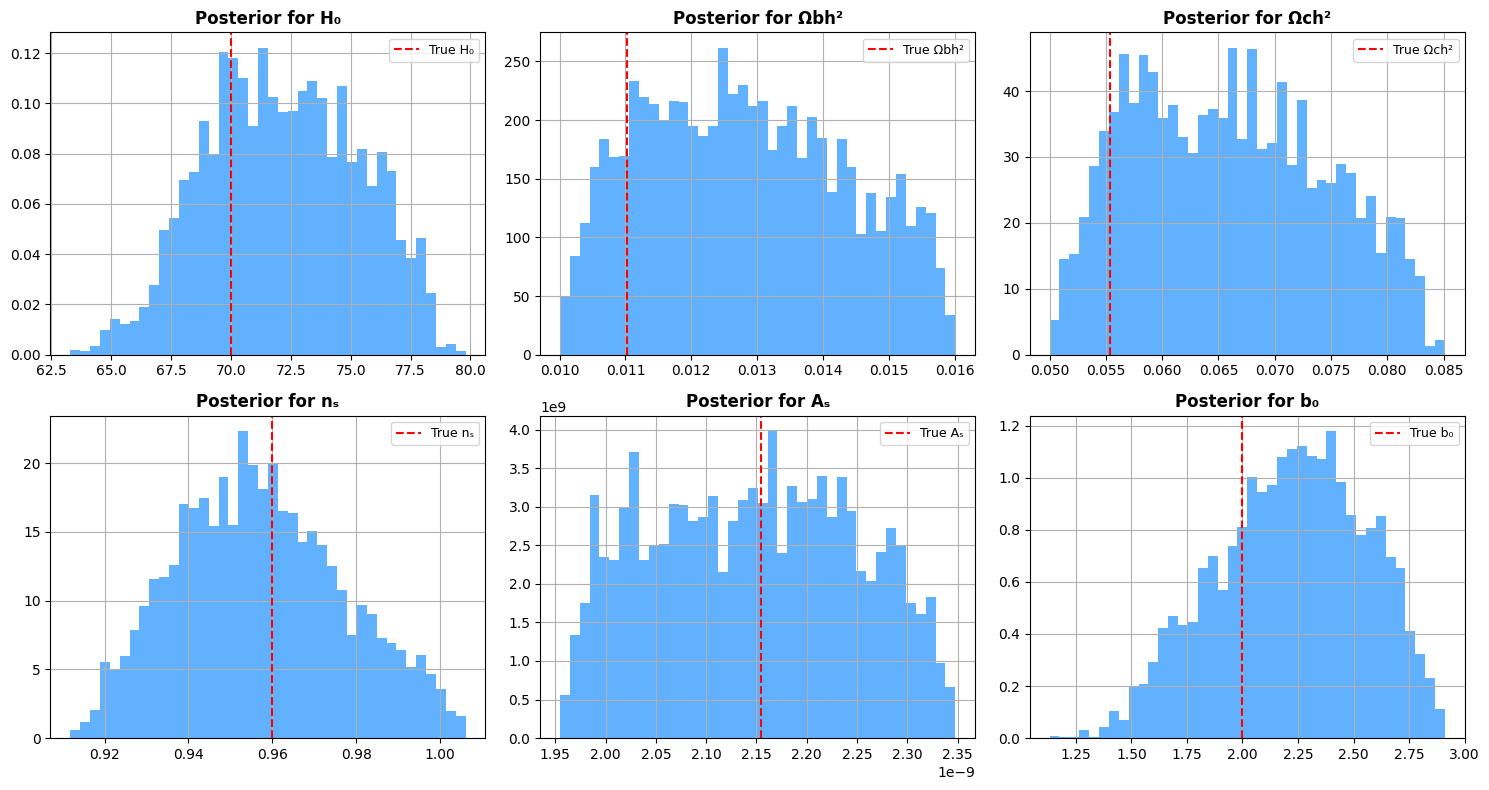

In [23]:
# --- Step 7: Create Plots ---
# Plot and save posterior distributions for all cosmological parameters

import os

print("Creating plots...")

# Ensure plots directory exists
os.makedirs("plots", exist_ok=True)

# --- Individual Histogram for H₀ ---
plt.figure(figsize=(8, 6))
plt.hist(samples[:, 0], bins=40, weights=weights, density=True,
         alpha=0.7, label='Posterior', color='dodgerblue')
plt.axvline(H0_fid, color='red', linestyle='--', label=f'True H₀ = {H0_fid:.1f}')
plt.xlabel(r'$H_0$ [km/s/Mpc]', fontsize=14)
plt.ylabel('Posterior Density', fontsize=14)
plt.title('Posterior for $H_0$', fontsize=16, fontweight='bold')
plt.legend()
plt.grid(True)
plt.savefig("plots/posterior_H0.png", dpi=300, bbox_inches='tight')
plt.close()

# --- Grid of Histograms for All Parameters ---
params_names = ["H₀", "Ωbh²", "Ωch²", "nₛ", "Aₛ", "b₀"]
fiducial_values = [H0_fid, ombh2_fid, omch2_fid, ns_fid, As_fid, 2.0]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, (ax, name, fid) in enumerate(zip(axes, params_names, fiducial_values)):
    ax.hist(samples[:, i], bins=40, weights=weights, density=True,
            alpha=0.7, color="dodgerblue")
    ax.axvline(fid, color="red", linestyle="--", label=f"True {name}")
    ax.set_title(f"Posterior for {name}", fontsize=12, fontweight="bold")
    ax.grid(True)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("plots/posteriors_all_params.png", dpi=300, bbox_inches="tight")
plt.show()


- # **Trace Plot Generation**


Creating additional analysis plots...


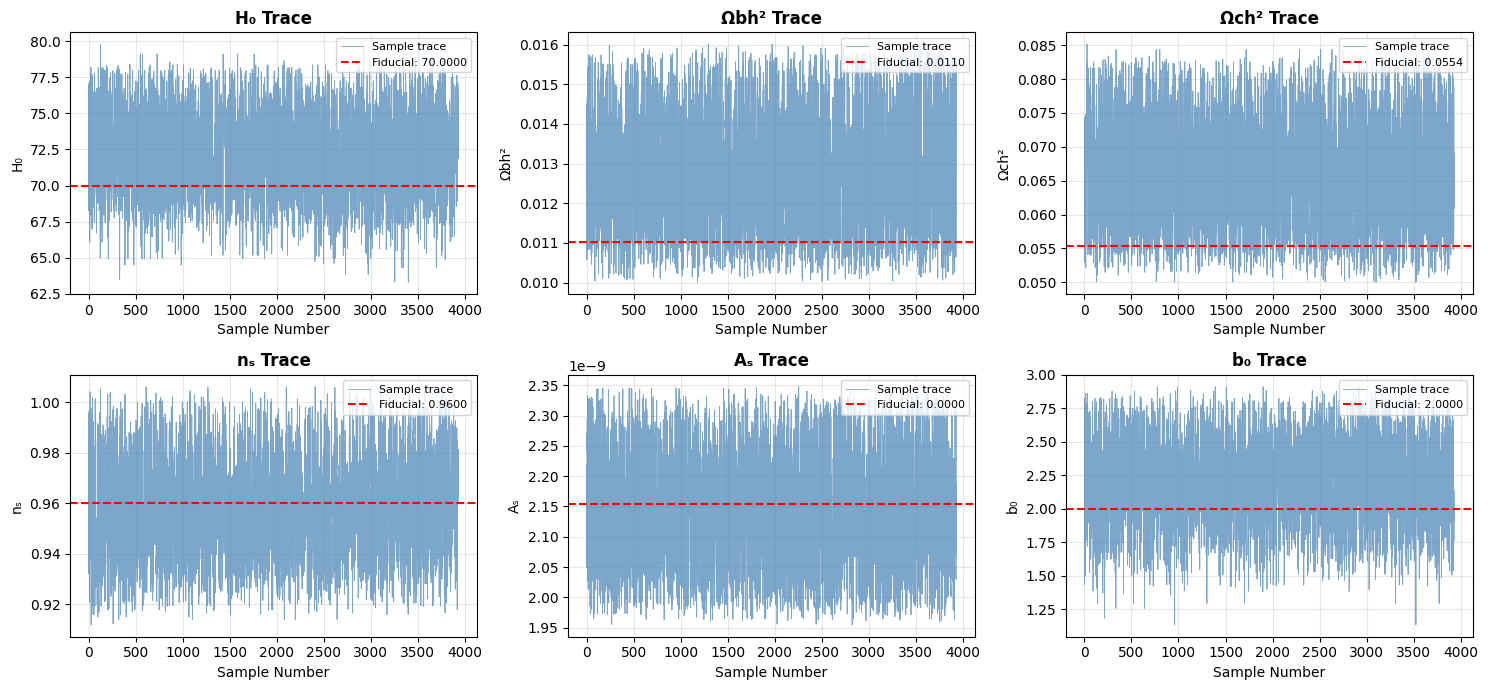

In [24]:
# --- Step 8: Additional Analysis Plots ---
# Generate trace plots to assess MCMC convergence across parameters.

print("\nCreating additional analysis plots...")

# Ensure directory exists
os.makedirs("plots", exist_ok=True)

# Determine subplot grid based on number of parameters
n_params = len(params_names)
ncols = 3
nrows = int(np.ceil(n_params / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows))
axes = axes.flatten()

# Trace plots for each parameter
for i, (name, fid) in enumerate(zip(params_names, fiducial_values)):
    axes[i].plot(samples[:, i], alpha=0.7, linewidth=0.6,
                 color='steelblue', label='Sample trace')
    axes[i].axhline(y=fid, color='red', linestyle='--',
                    label=f'Fiducial: {fid:.4f}')
    axes[i].set_title(f'{name} Trace', fontsize=12, fontweight="bold")
    axes[i].set_xlabel('Sample Number', fontsize=10)
    axes[i].set_ylabel(name, fontsize=10)
    axes[i].legend(loc='upper right', fontsize=8)
    axes[i].grid(True, alpha=0.3)

# Remove any unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Final layout & save
plt.tight_layout()
plt.savefig("plots/trace_plots.png", dpi=300, bbox_inches="tight")
plt.show()

- # **Autocorrelation Plot**


Creating autocorrelation plots...


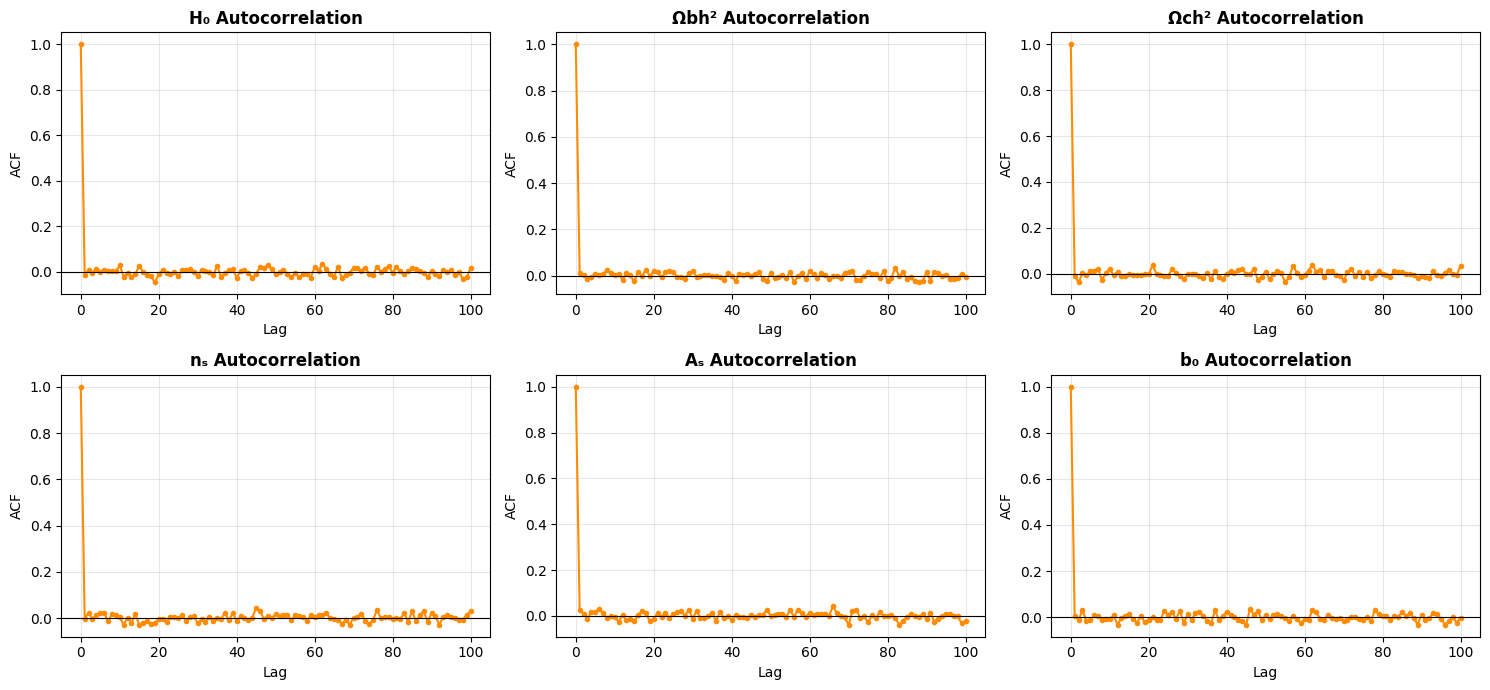

In [25]:
# --- Step 8b: Autocorrelation Analysis ---
# Compute and plot autocorrelation for each parameter chain

print("\nCreating autocorrelation plots...")

from statsmodels.tsa.stattools import acf

# Setup grid for autocorrelation plots
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 3.5 * nrows))
axes = axes.flatten()

max_lag = 100  # number of lags to compute

for i, (name, fid) in enumerate(zip(params_names, fiducial_values)):
    # Compute autocorrelation (skip weights here, use raw samples)
    acorr = acf(samples[:, i], nlags=max_lag, fft=True)

    axes[i].plot(range(max_lag + 1), acorr, marker='o',
                 linestyle='-', color='darkorange', markersize=3)
    axes[i].axhline(0, color='black', linewidth=0.8)
    axes[i].set_title(f'{name} Autocorrelation', fontsize=12, fontweight="bold")
    axes[i].set_xlabel('Lag', fontsize=10)
    axes[i].set_ylabel('ACF', fontsize=10)
    axes[i].grid(True, alpha=0.3)

# Remove unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Final layout & save
plt.tight_layout()
plt.savefig("plots/autocorrelation_plots.png", dpi=300, bbox_inches="tight")
plt.show()

- # **ESS via Two Negatives**

In [26]:
import numpy as np
from statsmodels.tsa.stattools import acf

def effective_sample_size_two_neg(chain, max_lag=100):
    """
    Compute ESS by summing autocorrelations until two consecutive negative lags occur.
    """
    acorr = acf(chain, nlags=max_lag, fft=True)[1:]  # skip lag 0
    acorr_sum = 0.0
    for k in range(len(acorr) - 1):
        if acorr[k] < 0 and acorr[k+1] < 0:
            break  # stop at first pair of consecutive negative lags
        if acorr[k] > 0:
            acorr_sum += acorr[k]
    ess = len(chain) / (1 + 2 * acorr_sum)
    return min(ess, len(chain))  # ESS cannot exceed total samples

# Compute ESS for each parameter
for i, name in enumerate(params_names):
    ess = effective_sample_size_two_neg(samples[:, i])
    print(f"{name}: ESS ≈ {ess:.1f} / {len(samples[:, i])} total samples")

H₀: ESS ≈ 3504.4 / 3933 total samples
Ωbh²: ESS ≈ 3824.3 / 3933 total samples
Ωch²: ESS ≈ 3933.0 / 3933 total samples
nₛ: ESS ≈ 3067.1 / 3933 total samples
Aₛ: ESS ≈ 3214.6 / 3933 total samples
b₀: ESS ≈ 3685.0 / 3933 total samples


- # **ESS Versus Lag Plot**

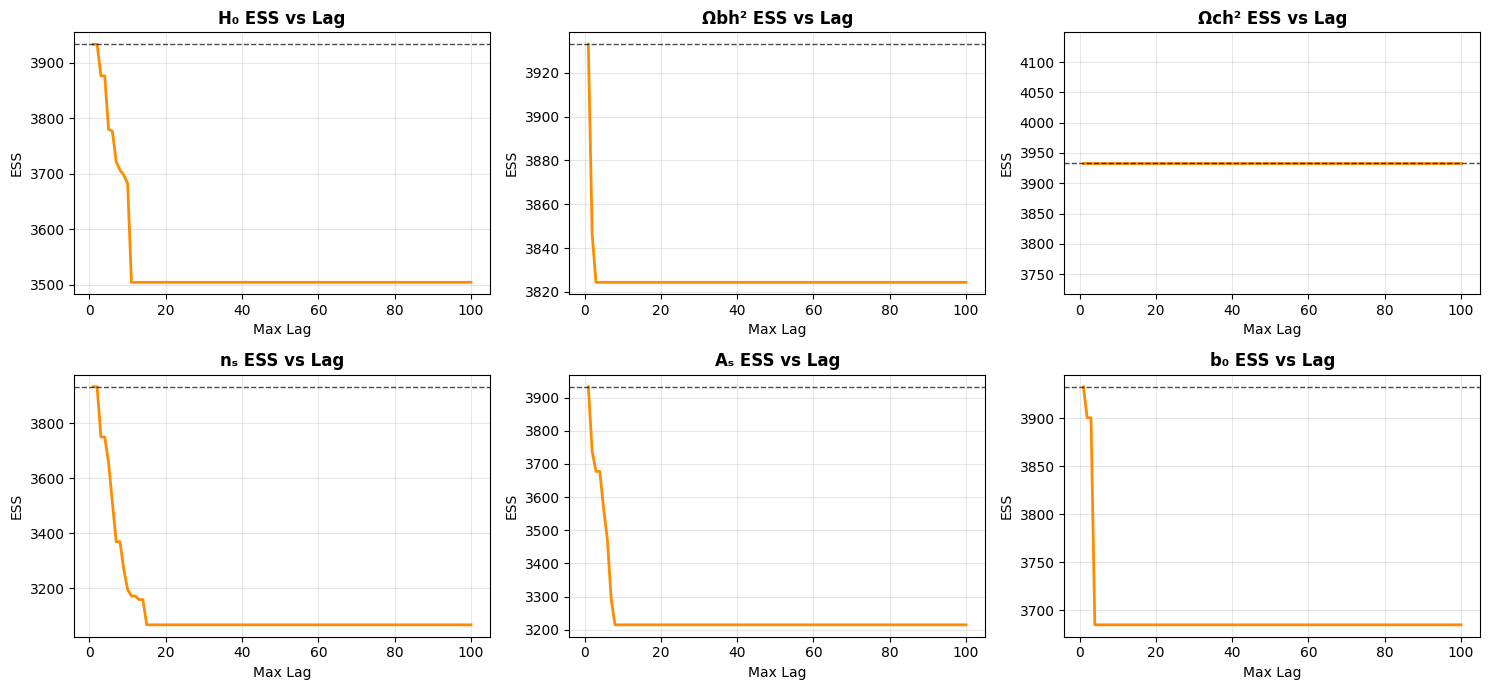

In [27]:
def running_ess_two_neg(chain, max_lag=100):
    """
    Compute ESS as a function of max lag using the two consecutive negative lags rule.
    """
    acorr = acf(chain, nlags=max_lag, fft=True)[1:]  # skip lag 0
    ess_values = []
    for lag in range(1, len(acorr)+1):
        acorr_sum = 0.0
        # sum until first pair of consecutive negative lags within current window
        for k in range(lag - 1):
            if acorr[k] < 0 and acorr[k+1] < 0:
                break
            if acorr[k] > 0:
                acorr_sum += acorr[k]
        ess = len(chain) / (1 + 2 * acorr_sum)
        ess_values.append(min(ess, len(chain)))  # ESS cannot exceed N
    return np.array(ess_values)

# Plot ESS vs lag for each parameter
max_lag = 100
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 3.5 * nrows))
axes = axes.flatten()

for i, name in enumerate(params_names):
    ess_vals = running_ess_two_neg(samples[:, i], max_lag=max_lag)
    axes[i].plot(range(1, max_lag + 1), ess_vals, color='darkorange', lw=2)
    axes[i].axhline(len(samples[:, i]), color='black', linestyle='--', lw=1, alpha=0.7)
    axes[i].set_title(f'{name} ESS vs Lag', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Max Lag', fontsize=10)
    axes[i].set_ylabel('ESS', fontsize=10)
    axes[i].grid(True, alpha=0.3)

# Remove unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("plots/ess_vs_lag_two_neg.png", dpi=300, bbox_inches="tight")
plt.show()

- # **ESS Curves Across Parameters**

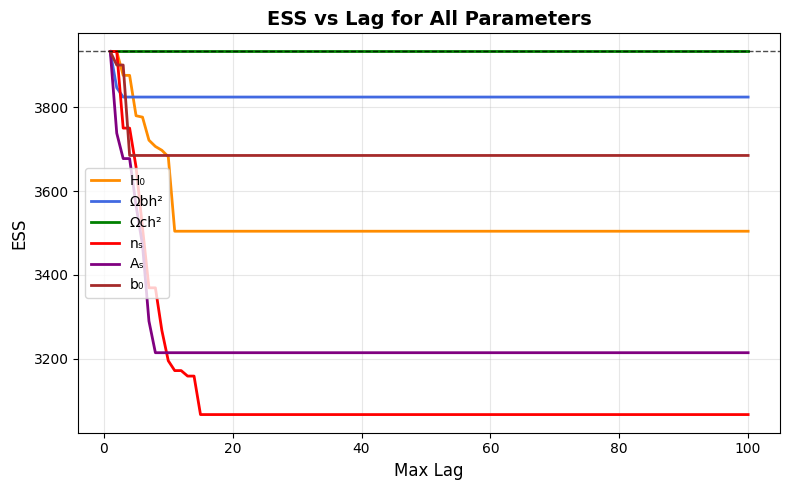

In [28]:
max_lag = 100
colors = ['darkorange', 'royalblue', 'green', 'red', 'purple', 'brown']  # one color per parameter

plt.figure(figsize=(8, 5))
for i, name in enumerate(params_names):
    ess_vals = running_ess_two_neg(samples[:, i], max_lag=max_lag)
    plt.plot(range(1, max_lag + 1), ess_vals, color=colors[i % len(colors)], lw=2, label=name)

# Total sample size line
plt.axhline(len(samples), color='black', linestyle='--', lw=1, alpha=0.7)

plt.xlabel('Max Lag', fontsize=12)
plt.ylabel('ESS', fontsize=12)
plt.title('ESS vs Lag for All Parameters', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("plots/ess_vs_lag_all_params.png", dpi=300, bbox_inches="tight")
plt.show()


- # **Corner & Triangle Plot Visualization**


Creating corner plots...


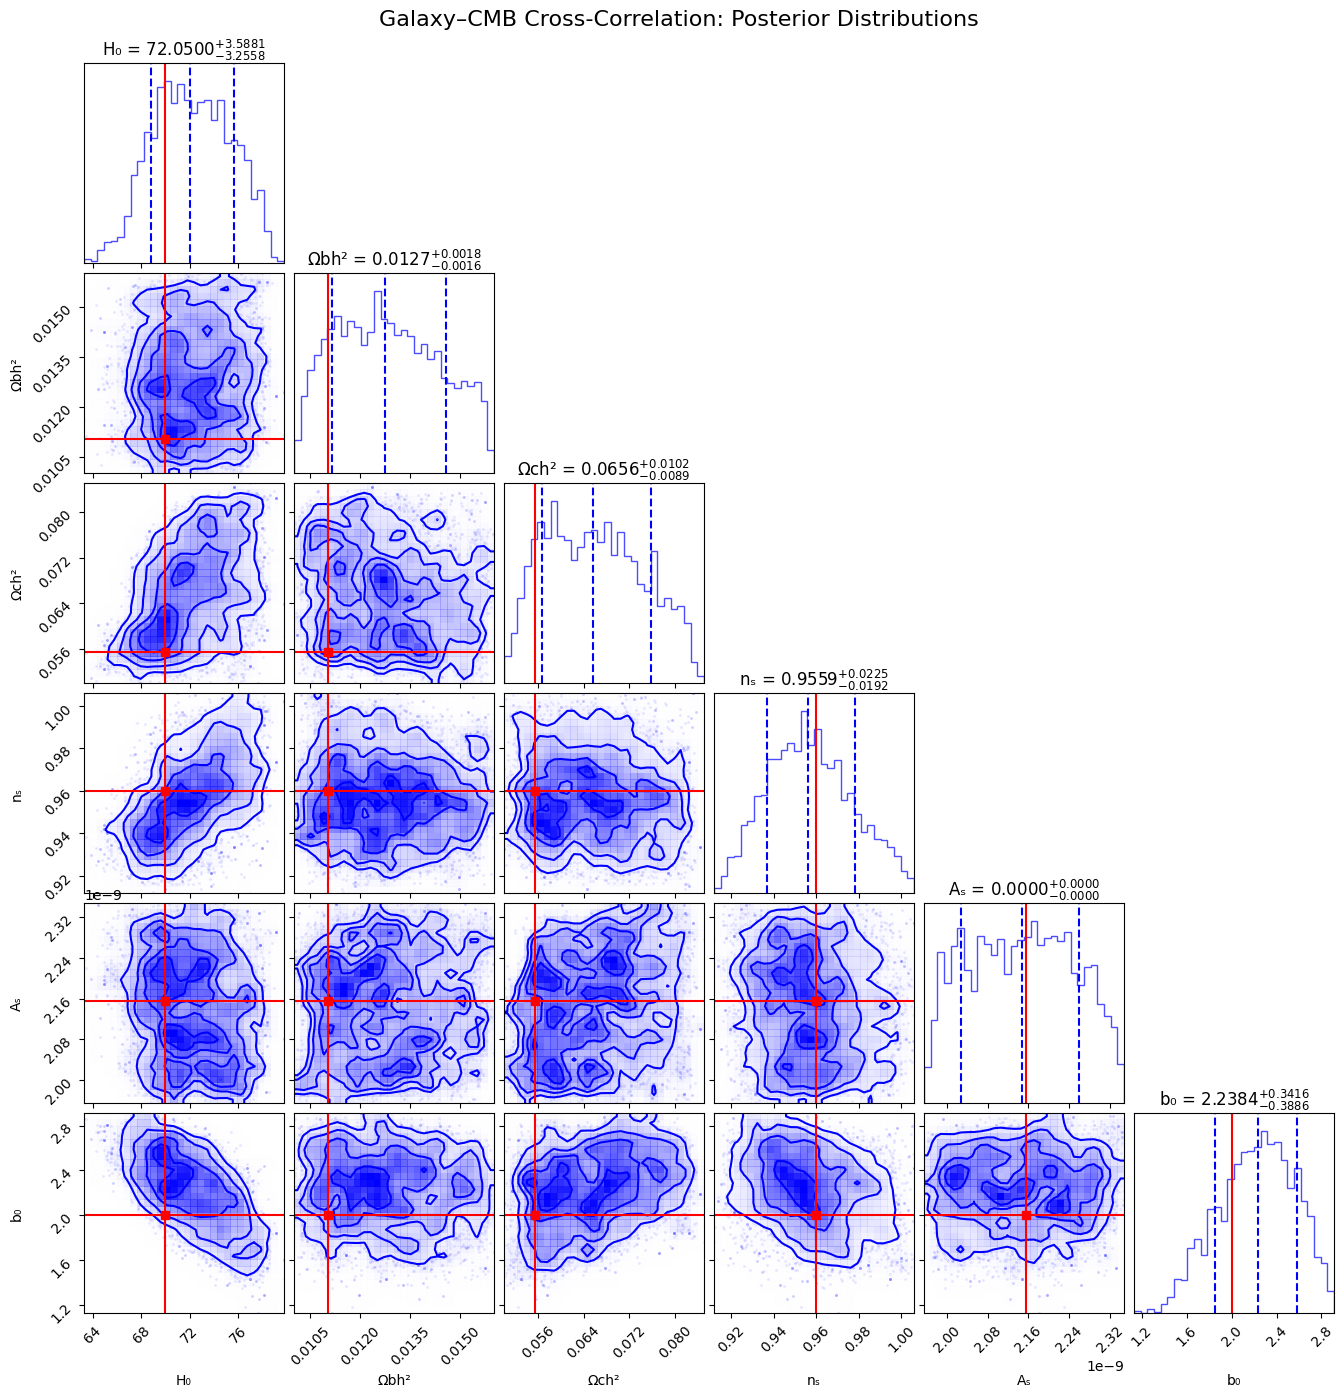

Creating GetDist triangle plot...
Removed no burn in


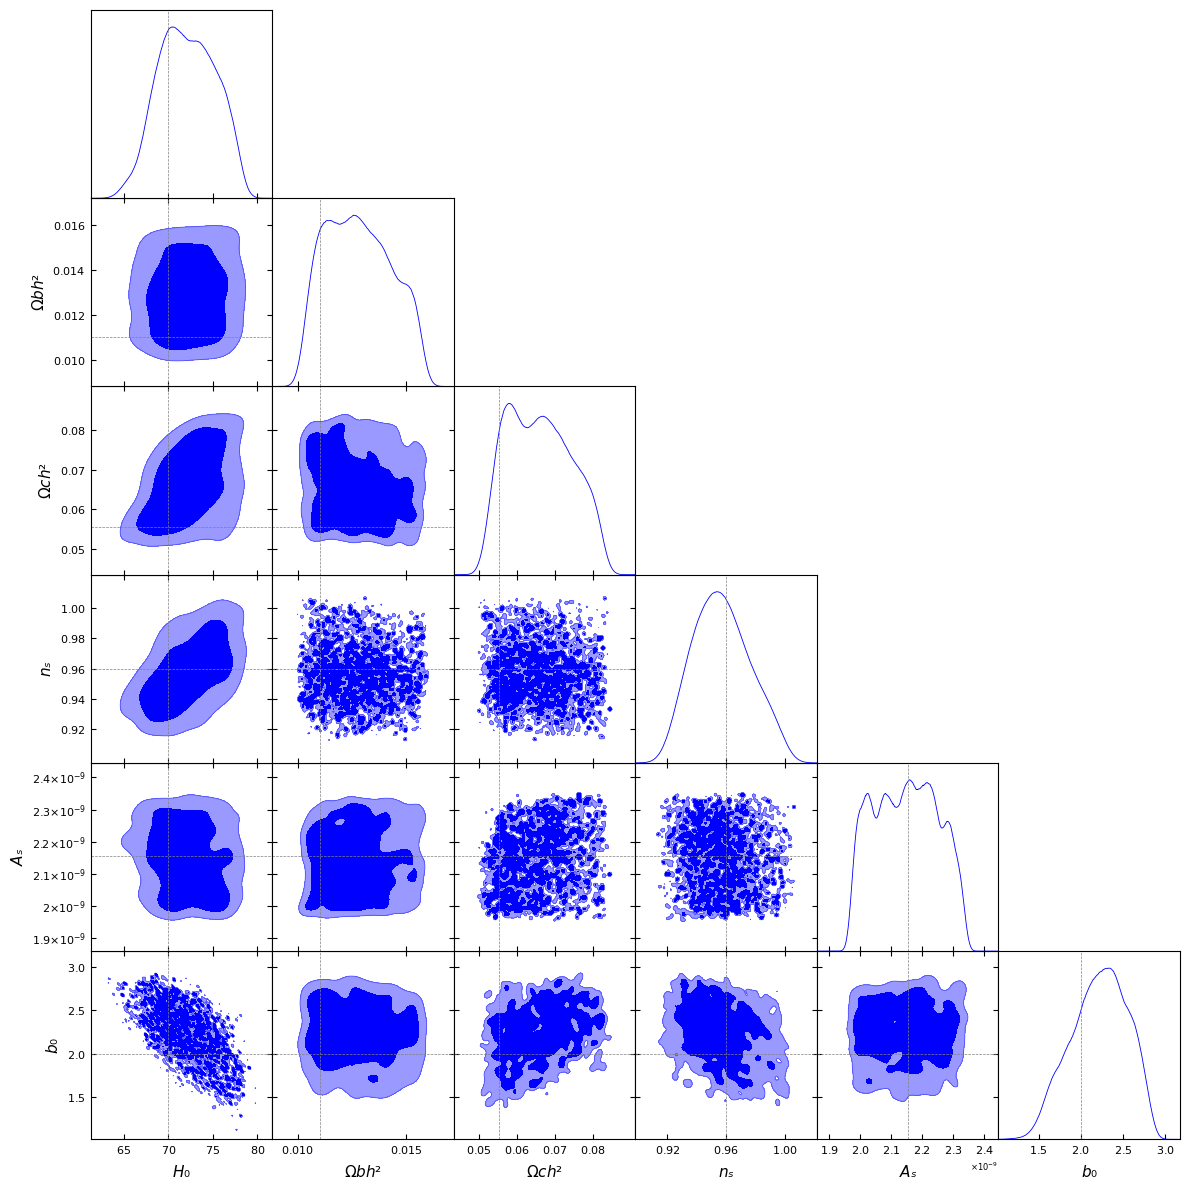

In [29]:
# --- Step 9: Generate Posterior Corner Plots ---
# Visualizes marginalized parameter distributions and correlations using two methods.

print("\nCreating corner plots...")

# 9A. Generate corner plot using corner.py
try:
    fig = corner.corner(
        samples,
        labels=params_names,
        truths=fiducial_values,
        weights=weights,
        show_titles=True,
        title_kwargs={"fontsize": 12},
        quantiles=[0.16, 0.5, 0.84],
        title_fmt='.4f',
        smooth=1.0,
        bins=30,
        color='blue',
        truth_color='red',
        hist_kwargs={'density': True, 'alpha': 0.7},
        scatter_kwargs={'alpha': 0.3, 's': 10}
    )

    fig.suptitle('Galaxy–CMB Cross-Correlation: Posterior Distributions', 
                 fontsize=16, y=1.01)

    plt.savefig('plots/corner_plot_corner.png', dpi=300, bbox_inches='tight')
    plt.show()

except Exception as e:
    print(f"corner.py plot failed: {e}")

# 9B. Generate triangle plot using GetDist
try:
    from getdist import MCSamples, plots as gd_plots

    print("Creating GetDist triangle plot...")

    samples_gd = MCSamples(samples=samples, weights=weights, names=params_names, labels=params_names)

    g = gd_plots.get_subplot_plotter()
    g.triangle_plot([samples_gd], filled=True, contour_colors=['blue'],
                    markers=dict(zip(params_names, fiducial_values)))
    
    plt.savefig('plots/corner_plot_getdist.png', dpi=300, bbox_inches='tight')
    plt.show()

except Exception as e:
    print(f"GetDist plot failed: {e}")